In [116]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [117]:
df = pd.read_csv('Animation_Movies.csv')
copy = pd.read_csv('Animation_Movies.csv')

In [118]:
features = ['runtime', 'vote_count', 'vote_average', 'budget', 'revenue','popularity']
stats_df = pd.DataFrame(columns=['Feature', 'Outlier', 'Median', 'Mode', 'Mean', 'Max', 'Min'])

In [119]:
def detect_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))]
    return outliers

In [120]:
for feature in features:
    median = df[feature].median()
    mode = df[feature].mode()[0] if not df[feature].mode().empty else None
    mean = df[feature].mean()
    max_value = df[feature].max()
    min_value = df[feature].min()
    outliers = detect_outliers(df[feature])
    new_row = pd.DataFrame({
        'Feature': [feature],
        'Outlier': [len(outliers)],
        'Median': [median],
        'Mode': [mode],
        'Mean': [mean],
        'Max': [max_value],
        'Min': [min_value]
    })
    stats_df = pd.concat([stats_df, new_row], ignore_index=True)
print(stats_df)

        Feature Outlier  Median Mode          Mean         Max  Min
0       runtime    9096     7.0    0  2.090141e+01        3720    0
1    vote_count    8400     0.0    0  4.039538e+01       19463    0
2  vote_average       0     0.0  0.0  2.597083e+00        10.0  0.0
3        budget    1603     0.0    0  5.759513e+05   260000000    0
4       revenue    1100     0.0    0  1.863464e+06  1450026933    0
5    popularity   10244     0.6  0.6  1.886233e+00    1008.942  0.0


<ipython-input-120-2b905d1d76bf>:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  stats_df = pd.concat([stats_df, new_row], ignore_index=True)


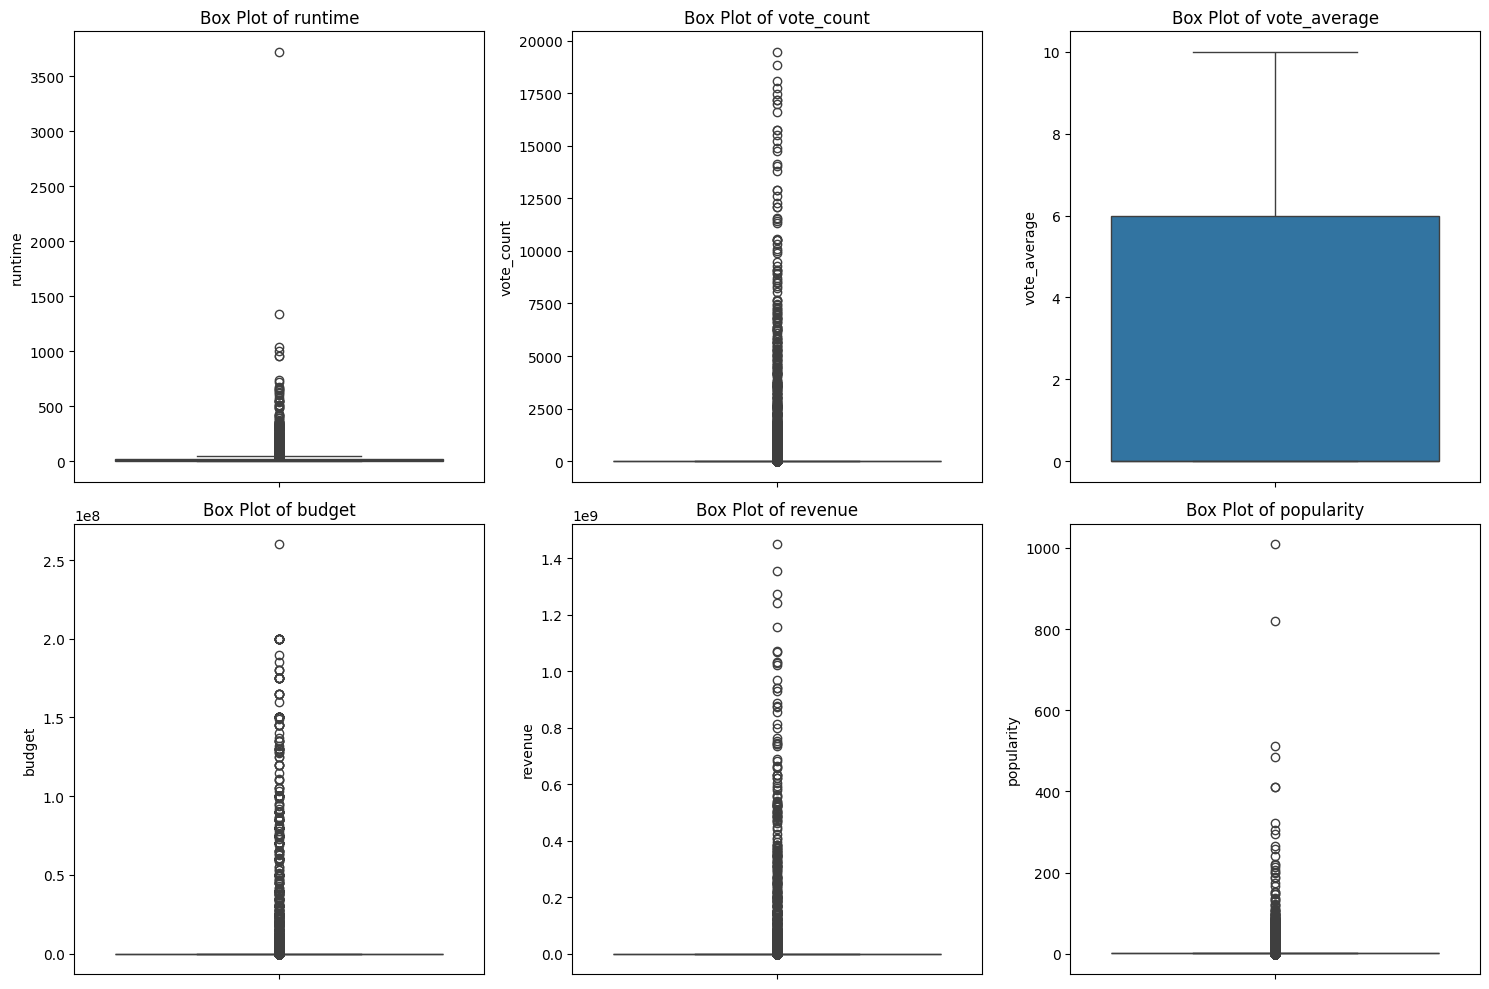

In [121]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [122]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
import nltk

In [123]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [124]:
null_value = ['id','title','release_date','backdrop_path','homepage','imdb_id','original_title','overview','poster_path','tagline']

In [125]:
import numpy as np
for value in null_value:
    if df[value].isnull().any():
        df[value] = df[value].replace({np.nan: 'null'})

In [126]:
mode_value = ['adult','original_language','genres','production_companies','production_countries','spoken_languages']

In [127]:
for value in mode_value:
    mode = df[value].mode()[0]
    df[value] = df[value].fillna(mode)

In [128]:
avg_value = ['vote_average','vote_count','revenue','runtime','budget']

In [129]:
for value in avg_value:
    avg = df[value].mean()
    df[value] = df[value].fillna(avg)

In [130]:
df_complete = df[df['popularity'].notna()]
df_missing = df[df['popularity'].isna()]

In [131]:
X_complete = df_complete[['vote_average']]
y_complete = df_complete['popularity']

In [132]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_complete, y_complete)

LinearRegression()

In [133]:
X_missing = df_missing[['vote_average']]
if len(X_missing) > 0:
  df.loc[df['popularity'].isna(), 'popularity'] = model.predict(X_missing)

In [134]:
columns_to_normalize = ['runtime', 'vote_count', 'vote_average', 'budget', 'revenue', 'popularity']
for column in columns_to_normalize:
    min_value = df[column].min()
    max_value = df[column].max()
    df[column] = (df[column] - min_value) / (max_value - min_value)

In [135]:
def remove_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))]
    return df.drop(outliers.index)

In [136]:
for feature in features:
    remove_outliers(feature)

In [137]:
df['profit'] = df['revenue'] / df['budget']

In [138]:
df['release_date'] = df['release_date'].str.extract('(\d+)').astype(float)

In [139]:
df['popularity'] = pd.cut(df['popularity'], bins=3, labels=['Low', 'Medium', 'High'])
df['profit'] = pd.cut(df['profit'], bins=[-float('inf'), 1, float('inf')], labels=['loss', 'profit'])

In [140]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    tokens = text.split()
    tokens = [word for word in tokens if word.lower() not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

In [141]:
df['overview'] = df['overview'].fillna('').apply(preprocess_text)
df['tagline'] = df['tagline'].fillna('').apply(preprocess_text)

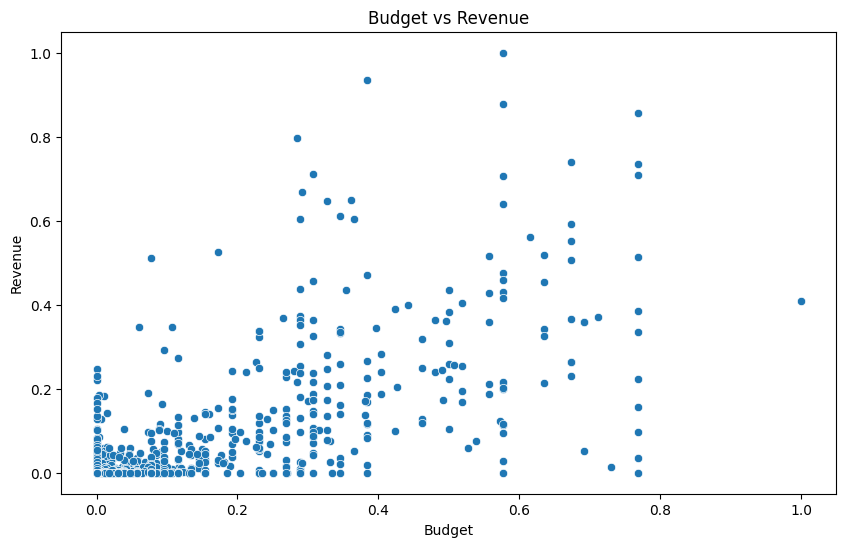

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.scatterplot(x='budget', y='revenue', data=df)
plt.title('Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='vote_average', y='vote_count', bins=30, pthresh=0.1, cmap="Blues", cbar=True)
plt.title('2D Histogram of Average Ratings and Number of Votes')
plt.xlabel('Average Rating')
plt.ylabel('Number of Votes')
plt.show()


In [ ]:
animation_df = df[df['genres'].str.contains('Animation', case=False, na=False)]
plt.figure(figsize=(10,6))
sns.lineplot(x='release_date', y=animation_df.groupby('release_date')['release_date'].count(), data=animation_df)
plt.title('Number of Movies Released Over Time')
plt.xlabel('release_date')
plt.ylabel('Number of Movies')
plt.show()

In [ ]:

plt.figure(figsize=(10, 6))
plt.scatter(df['budget'], df['vote_average'], alpha=0.5, color='orange')
plt.title('relation between budget and vote average')
plt.xlabel('budget')
plt.ylabel('vote average')
plt.show()

correlation = df['budget'].corr(df['vote_average'])
print(f'correlatin: {correlation}')

In [ ]:

plt.figure(figsize=(10, 6))
plt.hist(df['vote_count'], bins=30, color='blue', alpha=0.7)
plt.title('vote count distrubtion')
plt.xlabel('vote count')
plt.ylabel('movies')
plt.yscale('log')
plt.show()

In [ ]:
df['genres'] = df['genres'].fillna('')
df['genre_list'] = df['genres'].apply(lambda x: x.split(','))

genre_revenue = {}
for genres in df['genre_list']:
    for genre in genres:
        if genre.strip() not in genre_revenue:
            genre_data = df[df['genres'].str.contains(genre.strip())]
            avg_revenue = genre_data['revenue'].mean()
            genre_revenue[genre.strip()] = avg_revenue

genre_revenue_df = pd.DataFrame.from_dict(genre_revenue, orient='index', columns=['average_revenue']).sort_values(by='average_revenue', ascending=False)
genre_revenue_df.plot(kind='bar', figsize=(12, 6), legend=False)
plt.title('Average Revenue of Movies by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Revenue')
plt.show()

In [ ]:
genre_analysis = {}
for genres in df['genre_list']:
    for genre in genres:
        if genre.strip() not in genre_analysis:
            genre_data = df[df['genres'].str.contains(genre.strip())]
            avg_score = genre_data['vote_average'].mean()
            genre_count = genre_data.shape[0]
            genre_analysis[genre.strip()] = {'avg_score': avg_score, 'count': genre_count}

genre_df = pd.DataFrame.from_dict(genre_analysis, orient='index').sort_values(by='count', ascending=False)
print("Genre Analysis:")
print(genre_df)

In [ ]:
# تحلیل تولید کنندگان

In [ ]:
adult_data = df[df['adult'] == True]
non_adult_data = df[df['adult'] == False]
adult_stats = {
    'avg_vote': adult_data['vote_average'].mean(),
    'avg_revenue': adult_data['revenue'].mean(),
    'avg_popularity': adult_data['popularity'].mode()[0]
}
non_adult_stats = {
    'avg_vote': non_adult_data['vote_average'].mean(),
    'avg_revenue': non_adult_data['revenue'].mean(),
    'avg_popularity': non_adult_data['popularity'].mode()[0]
}

print("Adult Movies Stats:")
print(adult_stats)

print("Non-Adult Movies Stats:")
print(non_adult_stats)

In [158]:
successful_movies = df[df['profit'] == 'profit']

print("Financially Successful Movies:")
print(successful_movies[['title', 'budget', 'revenue']])

Financially Successful Movies:
                                           title    budget       revenue
2                                   Finding Nemo  0.361538  6.484952e-01
6                                      Toy Story  0.115385  2.719949e-01
7                                  The Lion King  0.173077  5.265113e-01
8                                The Incredibles  0.353846  4.354692e-01
9                                          Shrek  0.230769  3.364443e-01
...                                          ...       ...           ...
50525  Happy Little Submarine: Magic Box of Time  0.000000  5.591360e-03
50582          Maceracı Yüzgeçler: Büyük Gösteri  0.000000  7.108765e-05
51189   O Show da Luna – Das Ilhas ao Continente  0.000000  2.758569e-09
51209           Bulmaca Kulesi: Dev Kuşun Gizemi  0.000000  1.030912e-04
51544                        The Secret Princess  0.000000  3.448212e-04

[558 rows x 3 columns]


In [159]:
df['spoken_languages'] = df['spoken_languages'].fillna('')
df['language_list'] = df['spoken_languages'].apply(lambda x: x.split(','))
language_analysis = {}
for languages in df['language_list']:
    for language in languages:
        if language.strip() not in language_analysis:
            language_data = df[df['spoken_languages'].str.contains(language.strip())]
            language_count = language_data.shape[0]
            language_analysis[language.strip()] = language_count
language_df = pd.DataFrame.from_dict(language_analysis, orient='index', columns=['count']).sort_values(by='count', ascending=False)
print("Number of Movies by Language:")
print(language_df)

Number of Movies by Language:
             count
English      31542
No Language   6259
Japanese      4544
French        2007
Russian       1926
...            ...
Sinhalese        1
Ndebele          1
Igbo             1
Inupiaq          1
Nepali           1

[115 rows x 1 columns]


In [ ]:
inconsistent_entries = df[(df['revenue'] > 0) & ((df['budget'] == 0) | (df['budget'].isnull()))]
print(f"Number of inconsistent entries (revenue exists but budget is missing/zero): {inconsistent_entries.shape[0]}")


In [160]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_decade'] = (df['release_date'].dt.year // 10) * 10
release_count_per_decade = df['release_decade'].value_counts().sort_index()
print("Number of movies released per decade:")
print(release_count_per_decade)


Number of movies released per decade:
release_decade
1970.0    49808
Name: count, dtype: int64


In [ ]:
invalid_budget = df[df['budget'] < 0]
invalid_revenue = df[df['revenue'] < 0]
print(f"Number of invalid budget entries: {invalid_budget.shape[0]}")
print(f"Number of invalid revenue entries: {invalid_revenue.shape[0]}")


In [ ]:
missing_values = df[['release_date']].isnull().sum()
print("Number of missing values per column:")
print(missing_values)


In [161]:
total_entries = df.shape[0]

valid_release = df['release_date'].notna().sum() - missing_values['release_date']
valid_budget = df['budget'].notna().sum() - inconsistent_entries.shape[0] - invalid_budget.shape[0]
valid_revenue = df['revenue'].notna().sum() - inconsistent_entries.shape[0] - invalid_revenue.shape[0]


release_accuracy = (valid_release / total_entries) * 100
budget_accuracy = (valid_budget / total_entries) * 100
revenue_accuracy = (valid_revenue / total_entries) * 100


print(f"Release Date Accuracy: {release_accuracy:.2f}%")
print(f"Budget Accuracy: {budget_accuracy:.2f}%")
print(f"Revenue Accuracy: {revenue_accuracy:.2f}%")


Release Date Accuracy: 91.77%
Budget Accuracy: 99.13%
Revenue Accuracy: 99.13%
